# CLS Token vs Average Pooling Analysis

Compares CLS token pooling against global average pooling for ViT and DeiT
models across all datasets in the results (KNN-5 and Linear Probe).

All results are shown as **delta vs the CLS baseline**: positive = avg pooling is better.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv("../results/cls_token_experiment.csv")

# Derive pooling type and base model name
df["pooling"] = df["name"].apply(lambda x: "cls" if x.endswith("_cls") else "avg")
df["base_model"] = (
    df["name"]
    .str.replace(r"_(cls|avg)$", "", regex=True)
    .str.replace("_patch16_224", "", regex=False)
)
df["family"] = df["base_model"].apply(lambda x: "DeiT" if x.startswith("deit") else "ViT")

datasets = sorted(df["dataset"].unique())
print(
    f"{len(df)} rows — {df['base_model'].nunique()} models, "
    f"{df['method'].nunique()} methods, {df['pooling'].nunique()} pooling types, "
    f"{len(datasets)} datasets: {datasets}"
)

58 rows — 9 models, 2 methods, 2 pooling types, 2 datasets: ['m-eurosat', 'm-so2sat']


In [2]:
def pooling_table(df, method, dataset):
    """Pivot to base_model x pooling, showing accuracy and delta vs CLS baseline."""
    sub = df[(df["method"] == method) & (df["dataset"] == dataset)]
    piv = sub.pivot_table(index="base_model", columns="pooling", values="metric_value")
    if "avg" not in piv.columns or "cls" not in piv.columns:
        return None, None
    piv["delta"] = piv["avg"] - piv["cls"]
    piv = piv.sort_values("avg", ascending=False)

    combined = pd.DataFrame(index=piv.index)
    combined["avg"] = [f"{a:.3f} ({d:+.3f})" for a, d in zip(piv["avg"], piv["delta"])]
    combined["cls"] = [f"{c:.3f} (baseline)" for c in piv["cls"]]
    combined["Δ (avg − cls)"] = [f"{d:+.3f}" for d in piv["delta"]]
    return combined, piv

## 1. Accuracy Δ Tables (Avg − CLS)

Each cell shows the accuracy difference (avg pooling minus CLS pooling).
Positive = avg pooling wins. Rows sorted by mean Δ across datasets.

In [3]:
def delta_table(df, method):
    """Build a table of (avg - cls) deltas across all datasets for one method."""
    parts = {}
    for dataset in datasets:
        sub = df[(df["method"] == method) & (df["dataset"] == dataset)]
        piv = sub.pivot_table(index="base_model", columns="pooling", values="metric_value")
        if "avg" not in piv.columns or "cls" not in piv.columns:
            continue
        parts[dataset] = piv["avg"] - piv["cls"]
    if not parts:
        return None
    tbl = pd.DataFrame(parts)
    tbl["mean Δ"] = tbl.mean(axis=1)
    return tbl.sort_values("mean Δ", ascending=False)


for method, label in [("knn5", "KNN-5"), ("linear", "Linear Probe")]:
    tbl = delta_table(df, method)
    if tbl is None:
        continue
    print(f"\n### {label}  —  Δ accuracy (avg − cls)")
    display(tbl.style.format("{:+.3f}").background_gradient(cmap="RdYlGn", axis=None))

## 2. Delta Plot: Advantage of Avg Pooling over CLS Token

Green bars = avg pooling wins; red bars = CLS pooling wins.

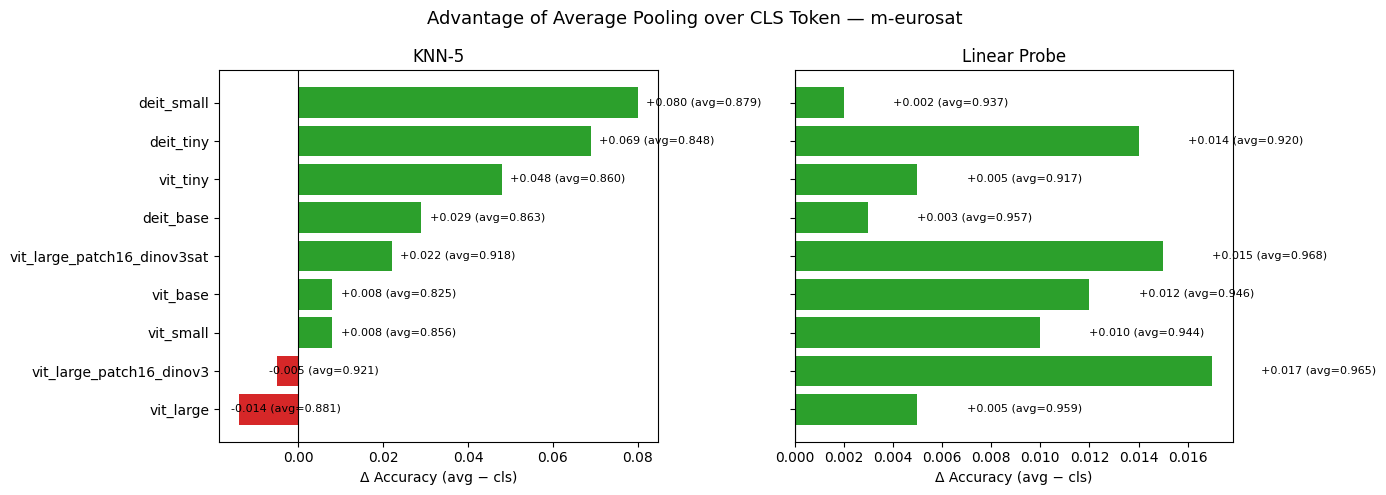

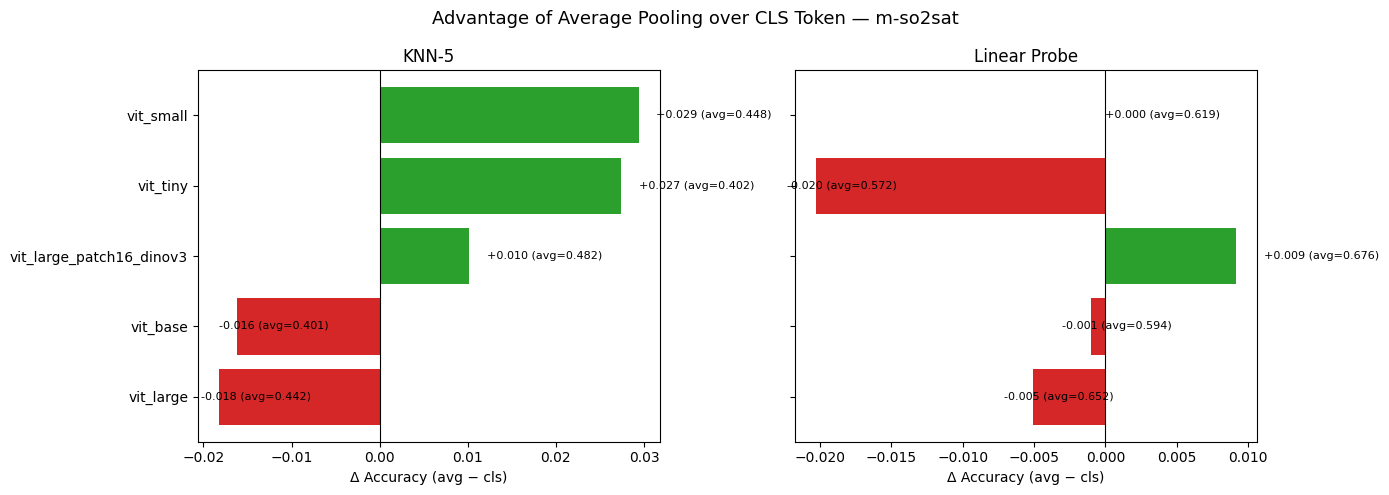

In [4]:
for dataset in datasets:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, method in zip(axes, ["knn5", "linear"]):
        _, piv = pooling_table(df, method, dataset)
        if piv is None:
            ax.set_visible(False)
            continue
        delta = piv["delta"].sort_values()

        colors = ["#2ca02c" if d >= 0 else "#d62728" for d in delta]
        bars = ax.barh(delta.index, delta.values, color=colors)
        ax.axvline(0, color="black", linewidth=0.8)

        for bar, d, model in zip(bars, delta.values, delta.index):
            x = bar.get_width()
            avg_val = piv.loc[model, "avg"]
            ax.text(
                x + 0.002 * np.sign(x),
                bar.get_y() + bar.get_height() / 2,
                f"{d:+.3f} (avg={avg_val:.3f})",
                va="center",
                fontsize=8,
            )

        title = "KNN-5" if method == "knn5" else "Linear Probe"
        ax.set_title(title)
        ax.set_xlabel("Δ Accuracy (avg − cls)")

    fig.suptitle(f"Advantage of Average Pooling over CLS Token — {dataset}", fontsize=13)
    plt.tight_layout()
    plt.show()

## 3. Confidence Interval Comparison

Accuracy with bootstrap 95% CI for each model and pooling type.

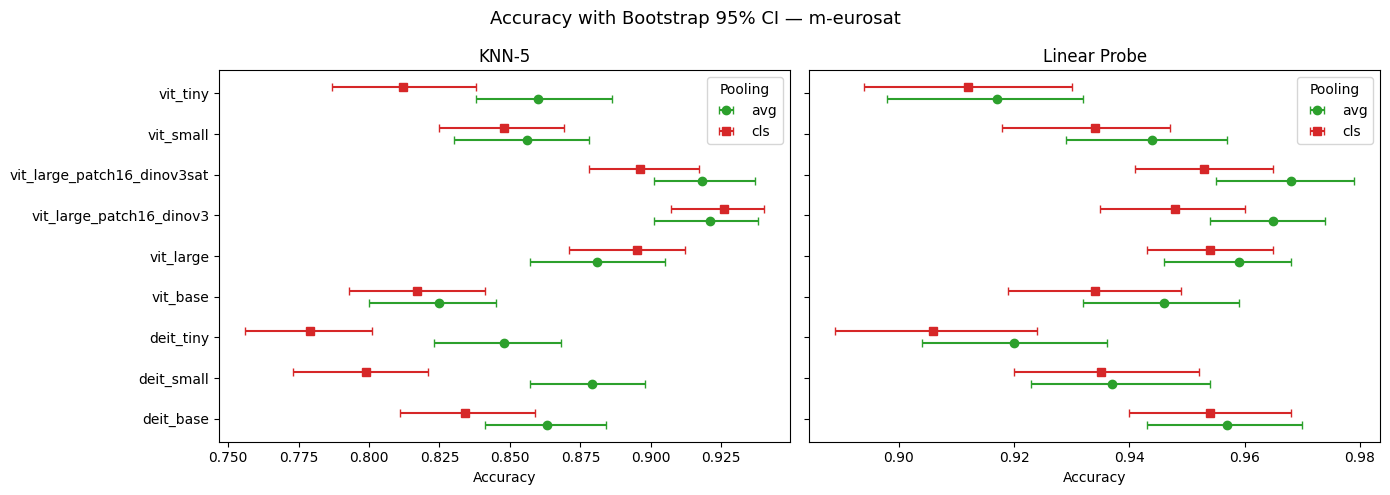

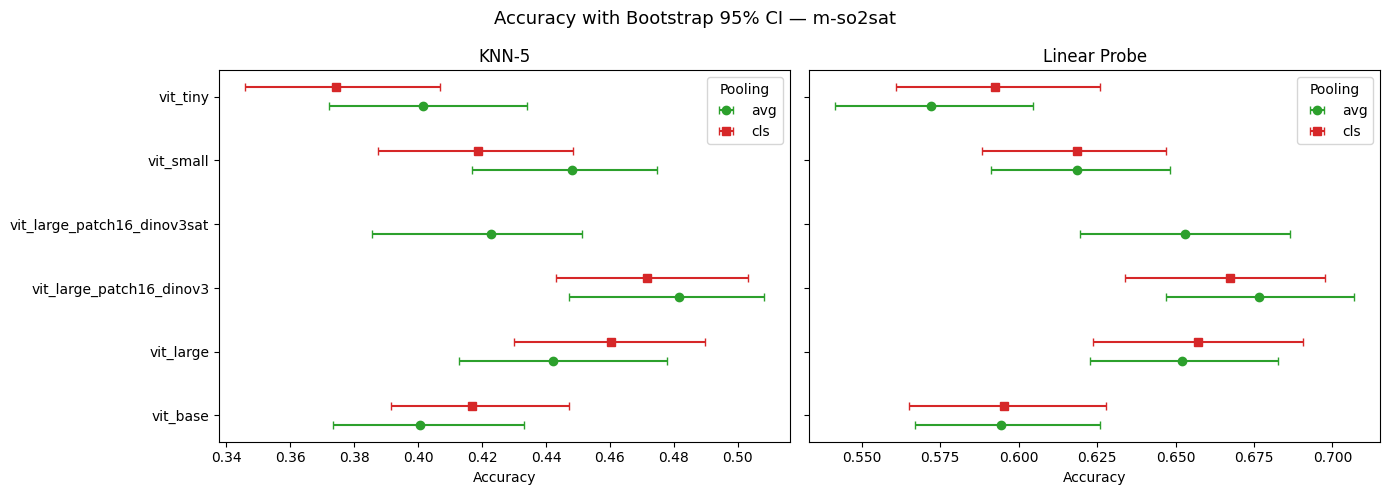

In [5]:
for dataset in datasets:
    sub_ds = df[df["dataset"] == dataset]
    if sub_ds.empty:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, method in zip(axes, ["knn5", "linear"]):
        sub = sub_ds[sub_ds["method"] == method].sort_values("base_model")
        models = sorted(sub["base_model"].unique())
        if not models:
            ax.set_visible(False)
            continue
        offsets = {"avg": -0.15, "cls": 0.15}
        markers = {"avg": "o", "cls": "s"}
        colors = {"avg": "#2ca02c", "cls": "#d62728"}

        for pooling in ["avg", "cls"]:
            p = sub[sub["pooling"] == pooling].set_index("base_model")
            present = [m for m in models if m in p.index]
            if not present:
                continue
            p = p.loc[present]
            y = [models.index(m) + offsets[pooling] for m in present]
            err_lo = p["metric_value"] - p["ci_lower"]
            err_hi = p["ci_upper"] - p["metric_value"]
            ax.errorbar(
                p["metric_value"],
                y,
                xerr=[err_lo.values, err_hi.values],
                fmt=markers[pooling],
                color=colors[pooling],
                label=pooling,
                capsize=3,
                markersize=6,
            )

        ax.set_yticks(range(len(models)))
        ax.set_yticklabels(models)
        title = "KNN-5" if method == "knn5" else "Linear Probe"
        ax.set_title(title)
        ax.set_xlabel("Accuracy")
        ax.legend(title="Pooling")

    fig.suptitle(f"Accuracy with Bootstrap 95% CI — {dataset}", fontsize=13)
    plt.tight_layout()
    plt.show()

## 4. Summary Statistics

In [6]:
for dataset in datasets:
    print(f"\n{'#' * 40}")
    print(f"  {dataset}")
    print(f"{'#' * 40}")
    for method in ["knn5", "linear"]:
        _, piv = pooling_table(df, method, dataset)
        if piv is None:
            continue
        delta = piv["delta"]
        title = "KNN-5" if method == "knn5" else "Linear Probe"
        print(f"\n  --- {title} ---")
        print(f"    Avg pooling wins : {(delta > 0).sum()} / {len(delta)} models")
        print(f"    Mean Δ           : {delta.mean():+.4f}")
        print(f"    Max Δ            : {delta.max():+.4f} ({delta.idxmax()})")
        print(f"    Min Δ            : {delta.min():+.4f} ({delta.idxmin()})")


########################################
  m-eurosat
########################################

  --- KNN-5 ---
    Avg pooling wins : 7 / 9 models
    Mean Δ           : +0.0272
    Max Δ            : +0.0800 (deit_small)
    Min Δ            : -0.0140 (vit_large)

  --- Linear Probe ---
    Avg pooling wins : 9 / 9 models
    Mean Δ           : +0.0092
    Max Δ            : +0.0170 (vit_large_patch16_dinov3)
    Min Δ            : +0.0020 (deit_small)

########################################
  m-so2sat
########################################

  --- KNN-5 ---
    Avg pooling wins : 3 / 6 models
    Mean Δ           : +0.0065
    Max Δ            : +0.0294 (vit_small)
    Min Δ            : -0.0183 (vit_large)

  --- Linear Probe ---
    Avg pooling wins : 1 / 6 models
    Mean Δ           : -0.0034
    Max Δ            : +0.0091 (vit_large_patch16_dinov3)
    Min Δ            : -0.0203 (vit_tiny)
